In [1]:
import torch

from laya.decision import TinyDecisionModel, TinyTransformerEncoder
from laya.training import predict, train_step
from laya.data import build_decision_sequence, encode_batch

In [2]:
torch.manual_seed(42)

tokens = [
    "[PAD]",
    "[STATE]",
    "[QUESTION]",
    "[OPTIONS]",
    "[MASK]",
    "the",
    "customer",
    "was",
    "charged",
    "twice",
    "needs",
    "technical",
    "support",
    "wants",
    "to",
    "buy",
    "a",
    "product",
    "which",
    "department",
    "should",
    "handle",
    "this",
    "billing",
    "sales",
]

token_to_id = {token: idx for idx, token in enumerate(tokens)}

mask_token_id = token_to_id["[MASK]"]
pad_token_id = token_to_id["[PAD]"]

options = [
    "billing",
    "technical",
    "sales",
]

examples = [
    (
        ["the", "customer", "was", "charged", "twice"],
        0,
    ),
    (
        ["the", "customer", "needs", "technical", "support"],
        1,
    ),
    (
        ["the", "customer", "wants", "to", "buy", "a", "product"],
        2,
    ),
]

question = [
    "which",
    "department",
    "should",
    "handle",
    "this",
]

In [3]:
sequence = build_decision_sequence(
    state_tokens=examples[0][0],
    question_tokens=question,
    options=options,
)

sequence

['[STATE]',
 'the',
 'customer',
 'was',
 'charged',
 'twice',
 '[QUESTION]',
 'which',
 'department',
 'should',
 'handle',
 'this',
 '[OPTIONS]',
 '[MASK]',
 'billing',
 '[MASK]',
 'technical',
 '[MASK]',
 'sales']

In [4]:
sequences = [build_decision_sequence(tk, question, options) for tk, x in examples]
sequences

[['[STATE]',
  'the',
  'customer',
  'was',
  'charged',
  'twice',
  '[QUESTION]',
  'which',
  'department',
  'should',
  'handle',
  'this',
  '[OPTIONS]',
  '[MASK]',
  'billing',
  '[MASK]',
  'technical',
  '[MASK]',
  'sales'],
 ['[STATE]',
  'the',
  'customer',
  'needs',
  'technical',
  'support',
  '[QUESTION]',
  'which',
  'department',
  'should',
  'handle',
  'this',
  '[OPTIONS]',
  '[MASK]',
  'billing',
  '[MASK]',
  'technical',
  '[MASK]',
  'sales'],
 ['[STATE]',
  'the',
  'customer',
  'wants',
  'to',
  'buy',
  'a',
  'product',
  '[QUESTION]',
  'which',
  'department',
  'should',
  'handle',
  'this',
  '[OPTIONS]',
  '[MASK]',
  'billing',
  '[MASK]',
  'technical',
  '[MASK]',
  'sales']]

In [5]:
token_ids = encode_batch(sequences, token_to_id)
token_ids, token_ids.shape

(tensor([[ 1,  5,  6,  7,  8,  9,  2, 18, 19, 20, 21, 22,  3,  4, 23,  4, 11,  4,
          24,  0,  0],
         [ 1,  5,  6, 10, 11, 12,  2, 18, 19, 20, 21, 22,  3,  4, 23,  4, 11,  4,
          24,  0,  0],
         [ 1,  5,  6, 13, 14, 15, 16, 17,  2, 18, 19, 20, 21, 22,  3,  4, 23,  4,
          11,  4, 24]]),
 torch.Size([3, 21]))

In [6]:
option_mask = token_ids == mask_token_id
option_mask.sum(dim=1)

tensor([3, 3, 3])

In [7]:
targets = torch.tensor([tg for _, tg in examples], dtype=torch.long)
targets

tensor([0, 1, 2])

In [8]:
# model
encoder = TinyTransformerEncoder(
    vocab_size=len(tokens),
    max_seq_len=64,
    d_model=32,
    n_heads=4,
    d_ff=64,
    n_layers=2,
    causal=False,
)

model = TinyDecisionModel(encoder, d_model=32, decision_hidden_dim=64)

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

In [10]:
# pre train
pre_train = predict(model, token_ids, option_mask)

for i, probabilities in enumerate(pre_train):
    predicted = probabilities.argmax().item()

    print(
        f"example={i} "
        f"target={targets[i].item()} "
        f"prediction={predicted} "
        f"probs={probabilities.tolist()}"
    )

example=0 target=0 prediction=0 probs=[0.345498263835907, 0.3426043391227722, 0.3118974268436432]
example=1 target=1 prediction=0 probs=[0.3450262248516083, 0.3423837721347809, 0.3125900328159332]
example=2 target=2 prediction=0 probs=[0.3680710792541504, 0.33527329564094543, 0.2966555953025818]


In [11]:
# train
losses = []

for s in range(200):
    loss = train_step(model, optimizer, token_ids, option_mask, targets)
    losses.append(loss)

losses[0], losses[-1]

(1.1165913343429565, 2.3047100512485486e-06)

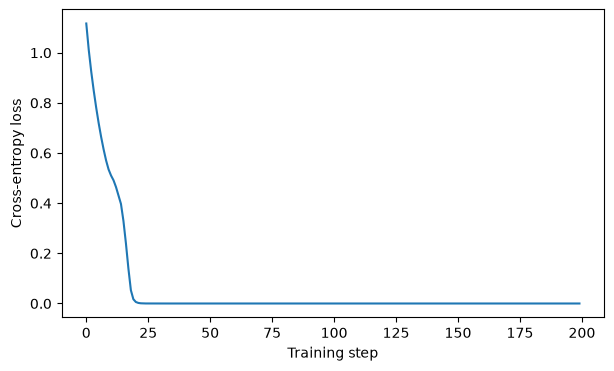

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.show()

In [13]:
after_train = predict(model, token_ids, option_mask)

for i, probabilities in enumerate(after_train):
    print(f"\nExample {i}")

    for option, probability in zip(
        options,
        probabilities,
    ):
        print(f"{option:10s} " f"{probability.item():.4f}")


Example 0
billing    1.0000
technical  0.0000
sales      0.0000

Example 1
billing    0.0000
technical  1.0000
sales      0.0000

Example 2
billing    0.0000
technical  0.0000
sales      1.0000


In [14]:
# out sample test set
test_state = [
    "the",
    "customer",
    "was",
    "charged",
]

test_sequence = build_decision_sequence(
    state_tokens=test_state,
    question_tokens=question,
    options=options,
)
test_ids = encode_batch(
    sequences=[test_sequence],
    token_to_id=token_to_id,
)

test_option_mask = test_ids == mask_token_id

test_probs = predict(
    model=model,
    token_ids=test_ids,
    option_mask=test_option_mask,
)

for option, probability in zip(
    options,
    test_probs[0],
):
    print(f"{option:10s} " f"{probability.item():.4f}")

billing    0.0001
technical  0.9994
sales      0.0006
